**Importing Libraries**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


**Load the Dataset**

In [10]:
df = pd.read_csv('/content/creditcard.csv')
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


**Exploratory Data Analysis (EDA)**

<Axes: xlabel='Class', ylabel='count'>

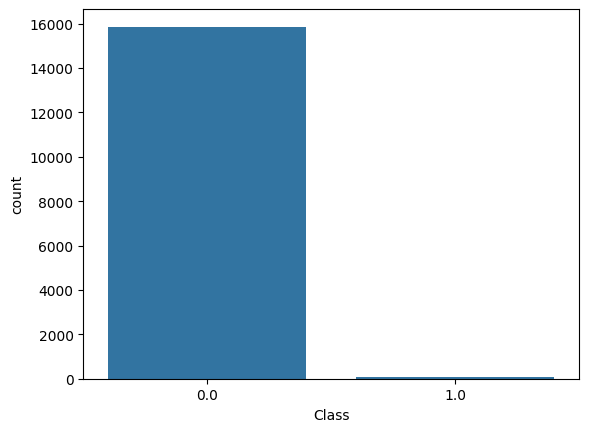

In [11]:
df['Class'].value_counts()
sns.countplot(x='Class', data=df)


In [12]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Time'], axis=1)


In [13]:
df=df.dropna()

**Splitting the data**

In [14]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


**Solving Class Imbalance Problem using SMOTE**

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(pd.Series(y_res).value_counts())


Class
0.0    12690
1.0    12690
Name: count, dtype: int64


**Model Training and Evaluation(Logistic Regression)**

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression()
lr.fit(X_res, y_res)
y_pred_lr = lr.predict(X_test)

# Calculate the metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

# Print the metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9934107310950737
Precision: 0.40625
Recall: 0.8666666666666667
F1-score: 0.5531914893617021


**Model Training and Evaluation(Random Forest Classifier)**

In [17]:
rf = RandomForestClassifier()
rf.fit(X_res, y_res)
y_pred_rf = rf.predict(X_test)

# Calculate the metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

# Print the metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9934107310950737
Precision: 0.40625
Recall: 0.8666666666666667
F1-score: 0.5531914893617021


**Model Training and Evaluation(XGBoost)**

In [19]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
xgb_model.fit(X_res, y_res)

y_pred_xgb = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9978035770316912
Precision: 0.75
Recall: 0.8
F1-score: 0.7741935483870968


In [20]:
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))


Logistic Regression Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      3172
         1.0       0.41      0.87      0.55        15

    accuracy                           0.99      3187
   macro avg       0.70      0.93      0.77      3187
weighted avg       1.00      0.99      0.99      3187

Random Forest Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3172
         1.0       0.86      0.80      0.83        15

    accuracy                           1.00      3187
   macro avg       0.93      0.90      0.91      3187
weighted avg       1.00      1.00      1.00      3187

XGBoost Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3172
         1.0       0.75      0.80      0.77        15

    accuracy                           1.00      3187
   macro avg       0.87      0.90      0.89      3187
weigh